## 2. Implementation

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from discretize import TensorMesh
from simpeg import maps, data as simpeg_data
from simpeg.electromagnetics import resistivity as dc
from discretize.utils import active_from_xyz
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

### Plotting Utilities

In [2]:
def get_contour_arrays(mesh, data):
    """
    Reshape flat cell-centered data into arrays suitable for contour plotting.
    
    Returns
    -------
    x_coords : 1D array of x coordinates
    z_coords : 1D array of z (y) coordinates  
    data_grid : 2D array shaped (nz, nx) for contour plotting
    """
    x_coords = mesh.cell_centers_x
    z_coords = mesh.cell_centers_y  # In 2D mesh, y is our z (depth)
    nx, nz = len(x_coords), len(z_coords)
    data_grid = data.reshape((nx, nz), order='F').T
    return x_coords, z_coords, data_grid


def plot_with_colorbar(mesh, data, ax, clim=None, cmap='viridis', label=''):
    """Plot mesh data with colorbar."""
    out = mesh.plot_image(data, ax=ax, grid=False, clim=clim)
    if cmap != 'viridis':
        out[0].set_cmap(cmap)
    plt.colorbar(out[0], ax=ax, label=label)
    ax.set_aspect('equal')
    return out[0]


print("Plotting utilities defined.")

Plotting utilities defined.


### Problem Setup: 2D DC Resistivity

In [3]:
# Domain and mesh setup
dx, dz = 5.0, 5.0
nx, nz = 62, 32
hx = dx * np.ones(nx)
hz = dz * np.ones(nz)
mesh = TensorMesh([hx, hz], origin=[-10, -nz*dz + 10])

print(f"Mesh: {mesh.nC} cells ({nx} x {nz})")
print(f"Domain: x=[10, {mesh.nodes_x.max()}], z=[{mesh.nodes_y.min()}, {mesh.nodes_y.max()}]")
mesh

active_cells = active_from_xyz(mesh, np.array([[0, 0], [0, 0]]))
print(f"Active cells: {active_cells.sum()} out of {mesh.nC}")
mesh

Mesh: 1984 cells (62 x 32)
Domain: x=[10, 300.0], z=[-150.0, 10.0]
Active cells: 1860 out of 1984


TensorMesh: 1,984 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     62        -10.00        300.00      5.00      5.00    1.00
   y     32       -150.00         10.00      5.00      5.00    1.00

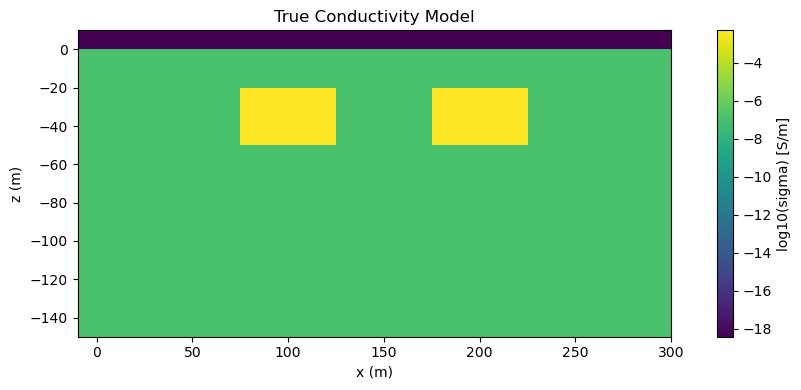

In [4]:
# True model: conductive block
sigma_air = np.log(1e-8)        # S/m (air)
sigma_background = np.log(1e-3)  # S/m (resistive)
sigma_anomaly = np.log(1e-1)     # S/m (conductive)

block_x1 = [75, 125]  # x extent
block_z1 = [-50, -20]  # z extent (depth)

block_x2 = [175, 225]  # x extent for initial model
block_z2 = [-50, -20]  # z extent (depth) for initial

sigma_true = sigma_background * np.ones(mesh.nC)
sigma_true[~active_cells] = sigma_air
block_inds = (
    (mesh.cell_centers[:, 0] >= block_x1[0]) & 
    (mesh.cell_centers[:, 0] <= block_x1[1]) &
    (mesh.cell_centers[:, 1] >= block_z1[0]) & 
    (mesh.cell_centers[:, 1] <= block_z1[1])
)

block_inds_2 = (
    (mesh.cell_centers[:, 0] >= block_x2[0]) & 
    (mesh.cell_centers[:, 0] <= block_x2[1]) &
    (mesh.cell_centers[:, 1] >= block_z2[0]) & 
    (mesh.cell_centers[:, 1] <= block_z2[1])
)

sigma_true[block_inds] = sigma_anomaly
sigma_true[block_inds_2] = sigma_anomaly
# Plot true model
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plot_with_colorbar(mesh, (sigma_true), ax, label='log10(sigma) [S/m]')
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title('True Conductivity Model')
plt.tight_layout()
plt.show() 



In [5]:
# Survey setup: Dipole-Dipole configuration
n_electrodes = 19
electrode_spacing = 15.0
electrode_x = np.linspace(20, 20 + (n_electrodes-1)*electrode_spacing, n_electrodes)
electrode_locations = np.c_[electrode_x, np.zeros(n_electrodes)]

print(f"Electrodes: {n_electrodes} at x = [{electrode_x.min():.0f}, {electrode_x.max():.0f}] m")

# Generate dipole-dipole survey
source_list = []
n_levels = 6

for i in range(n_electrodes - 3):
    A_loc = electrode_locations[i]
    B_loc = electrode_locations[i + 1]
    rx_list = []
    for n in range(1, min(n_levels + 1, n_electrodes - i - 2)):
        M_loc = electrode_locations[i + 1 + n]
        N_loc = electrode_locations[i + 2 + n] if (i + 2 + n) < n_electrodes else None
        if N_loc is not None:
            rx = dc.receivers.Dipole(
                locations_m=M_loc.reshape(1, -1),
                locations_n=N_loc.reshape(1, -1)
            )
            rx_list.append(rx)
    if rx_list:
        src = dc.sources.Dipole(receiver_list=rx_list, location_a=A_loc, location_b=B_loc)
        source_list.append(src)

survey = dc.Survey(source_list)
print(f"Survey: {len(source_list)} sources, {survey.nD} data points")

Electrodes: 19 at x = [20, 290] m
Survey: 16 sources, 81 data points


In [6]:
# Create DC simulation and generate synthetic data
sim_map = maps.ExpMap(mesh)  # Map from log-conductivity to conductivity
simulation = dc.Simulation2DNodal(
    mesh, survey=survey, sigmaMap=sim_map
)
data_true = simulation.dpred(sigma_true)

# Add noise
noise_floor = 1e-6
relative_error = 0.05
noise_std = relative_error * np.abs(data_true) + noise_floor
noise = noise_std * np.random.randn(len(data_true))
data_obs = data_true + noise

print(f"Data range: [{data_obs.min():.2e}, {data_obs.max():.2e}]")
print(f"Noise: {100*relative_error}% + {noise_floor:.1e} floor")

INFO: Setting the default solver 'Pardiso' for the 'Simulation2DNodal'.
To avoid receiving this message, pass a solver to the simulation. For example:

  from simpeg.utils import get_default_solver

  solver = get_default_solver()
  simulation = Simulation2DNodal(solver=solver, ...)


Data range: [-3.99e+00, -1.08e-02]
Noise: 5.0% + 1.0e-06 floor


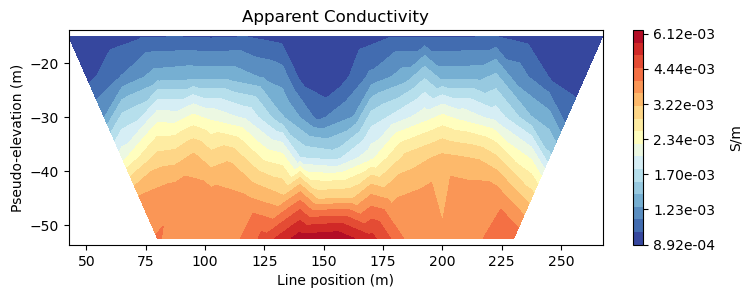

In [7]:
###-----------Plot Pseudosection-----------###
from simpeg.electromagnetics.static.utils.static_utils import (
    plot_pseudosection,
    apparent_resistivity_from_voltage,
)

from matplotlib import cm

# Get apparent conductivities from volts and survey geometry
apparent_conductivities = 1 / apparent_resistivity_from_voltage(survey, data_true)

# Plot apparent conductivity pseudo-section
fig = plt.figure(figsize=(8, 2.75))
ax1 = fig.add_axes([0.1, 0.15, 0.75, 0.78])
plot_pseudosection(
    survey,
    dobs=apparent_conductivities,
    plot_type="contourf",
    ax=ax1,
    scale="log",
    cbar_label="S/m",
    mask_topography=True,
    contourf_opts={"levels": 20, "cmap": cm.RdYlBu_r},
)
ax1.set_title("Apparent Conductivity")
plt.show()

### RBF Level Set Setup

In [8]:
from scipy.spatial.distance import cdist

def alpha_bound(alpha_raw):
    """Keep bounded coefficients for stability."""
    return np.arctan(alpha_raw * 0.5)

def alpha_bound_deriv(alpha_raw):
    return 2 / (4 + alpha_raw**2)

# ------------------------------------------------------------------ #
def rbf_kernel(params, xyz, m, return_deriv=False, use_normalised_C=True):
    # ------- unpack params ---------------------------------------------------
    centres = params[0]
    N = centres.shape[0]
    eps = params[1]  # Controls sigmoid steepness
    rbf_w = params[2:2+N] 

    #using wendland functions with compact support (C2 continuity) as RBFs
    def wendland_c2(r, w):
        """Wendland C2 compactly supported RBF."""
        r_scaled = r / w
        mask = r_scaled < 1
        phi = np.zeros_like(r)
        phi[mask] = (1 - r_scaled[mask])**4 * (4 * r_scaled[mask] + 1)
        return phi
    

    # Convert to numpy arrays
    centres = np.asarray(centres, dtype=float)
    eps = float(eps)
    rbf_w = np.asarray(rbf_w, dtype=float)
    xyz = np.asarray(xyz, dtype=float)
    m = np.asarray(m, dtype=float)

    # ------- split full model ------------------------------------------------
    alpha_raw = m[:N]
    c_low = (sigma_background) #m[N]
    c_high = (sigma_anomaly) #m[N+1]
    
    # ------- bounded shape coefficients -------------------------------
    alpha_bounded = alpha_bound(alpha_raw) 
    alpha_prime = alpha_bound_deriv(alpha_raw) 

    # ------- Gaussian RBF matrix ψ(x) ---------------------------------------
    # cdist computes pairwise distances
    distances = cdist(xyz, centres, metric='euclidean')
    psi = np.exp(-((distances**2) /(rbf_w[np.newaxis, :]**2)))
    #psi = wendland_c2(distances, rbf_w[np.newaxis, :])
    # ------- HEAVISIDE APPROACH (Level Set) ---------------------------------
    # Level set field; interface at phi = 0
    phi = psi @ alpha_bounded
    print(f"Phi range: [{phi.min():.2f}, {phi.max():.2f}]")
    print(f"psi range: [{psi.min():.2e}, {psi.max():.2e}]")
    arg = (np.pi * phi / eps)
    H = 0.5 * (1.0 + (2.0 / np.pi) * np.arctan(arg))
    H_prime = 1.0 / eps / (1.0 + arg**2)
    print(H.min(), H.max())
    # ------- compute physical property model  ----------------------------
    f = c_low + (c_high - c_low) * H 

    if not return_deriv:
        return f

    # ------- Analytic derivative calculation -------------------------------------------------
    # Shape block wrt alpha_raw (n_cells x N)
    J_alpha = psi * alpha_prime[np.newaxis, :] * ((c_high - c_low) * H_prime)[:, np.newaxis]

    # Only alpha parameters are inverted in this setup
    return J_alpha

In [9]:
# RBF centers on a coarse grid
n_rbf_x, n_rbf_z = 12, 12
rbf_x = np.linspace(0, 300, n_rbf_x)
rbf_z = np.linspace(-150, -0, n_rbf_z)
rbf_xx, rbf_zz = np.meshgrid(rbf_x, rbf_z)
rbf_centers = np.c_[rbf_xx.ravel(), rbf_zz.ravel()]

rbf_dist = cdist(rbf_centers, rbf_centers, metric='euclidean')
np.fill_diagonal(rbf_dist, np.inf)
rbf_spacing = np.median(np.min(rbf_dist, axis=1))
rbf_w = np.full(rbf_centers.shape[0], rbf_spacing)

extra_params = [rbf_centers, 10] + list(rbf_w)
alpha_init = -5.0 * np.ones(rbf_centers.shape[0])  # Initial guess: zero RBF coeffs

## INITIAL MODEL ##
params = np.r_[alpha_init]#, sigma_background, sigma_anomaly])  # Initial guess: zero RBF coeffs, background contrast
n_params = len(params)

print(f"Number of RBF parameters: {n_params}")
print(f"Dimensionality reduction: {mesh.nC} -> {n_params} ({100*n_params/mesh.nC:.1f}%)")
print(f"Compression ratio: {mesh.nC / n_params:.1f}x")

Number of RBF parameters: 144
Dimensionality reduction: 1984 -> 144 (7.3%)
Compression ratio: 13.8x


## Hyperparameter testing

In [10]:
# compute RBF indices for block indices in true model add buffer of 2 RBFs around the blocks
buffer = 0# rbf_spacing
rbf_block1_inds = np.all((rbf_centers >= [block_x1[0] - buffer, block_z1[0] - buffer]) & (rbf_centers <= [block_x1[1] + buffer, block_z1[1] + buffer]), axis=1)
rbf_block2_inds = np.all((rbf_centers >= [block_x2[0] - buffer, block_z2[0] - buffer]) & (rbf_centers <= [block_x2[1] + buffer, block_z2[1] + buffer]), axis=1)    
alpha_init[rbf_block1_inds] = 5.0  # Higher initial conductivity in block 1
alpha_init[rbf_block2_inds] = 5.0  # Higher initial conductivity
params = np.r_[alpha_init]

### Epsilon Hyperparameter Impact Figure

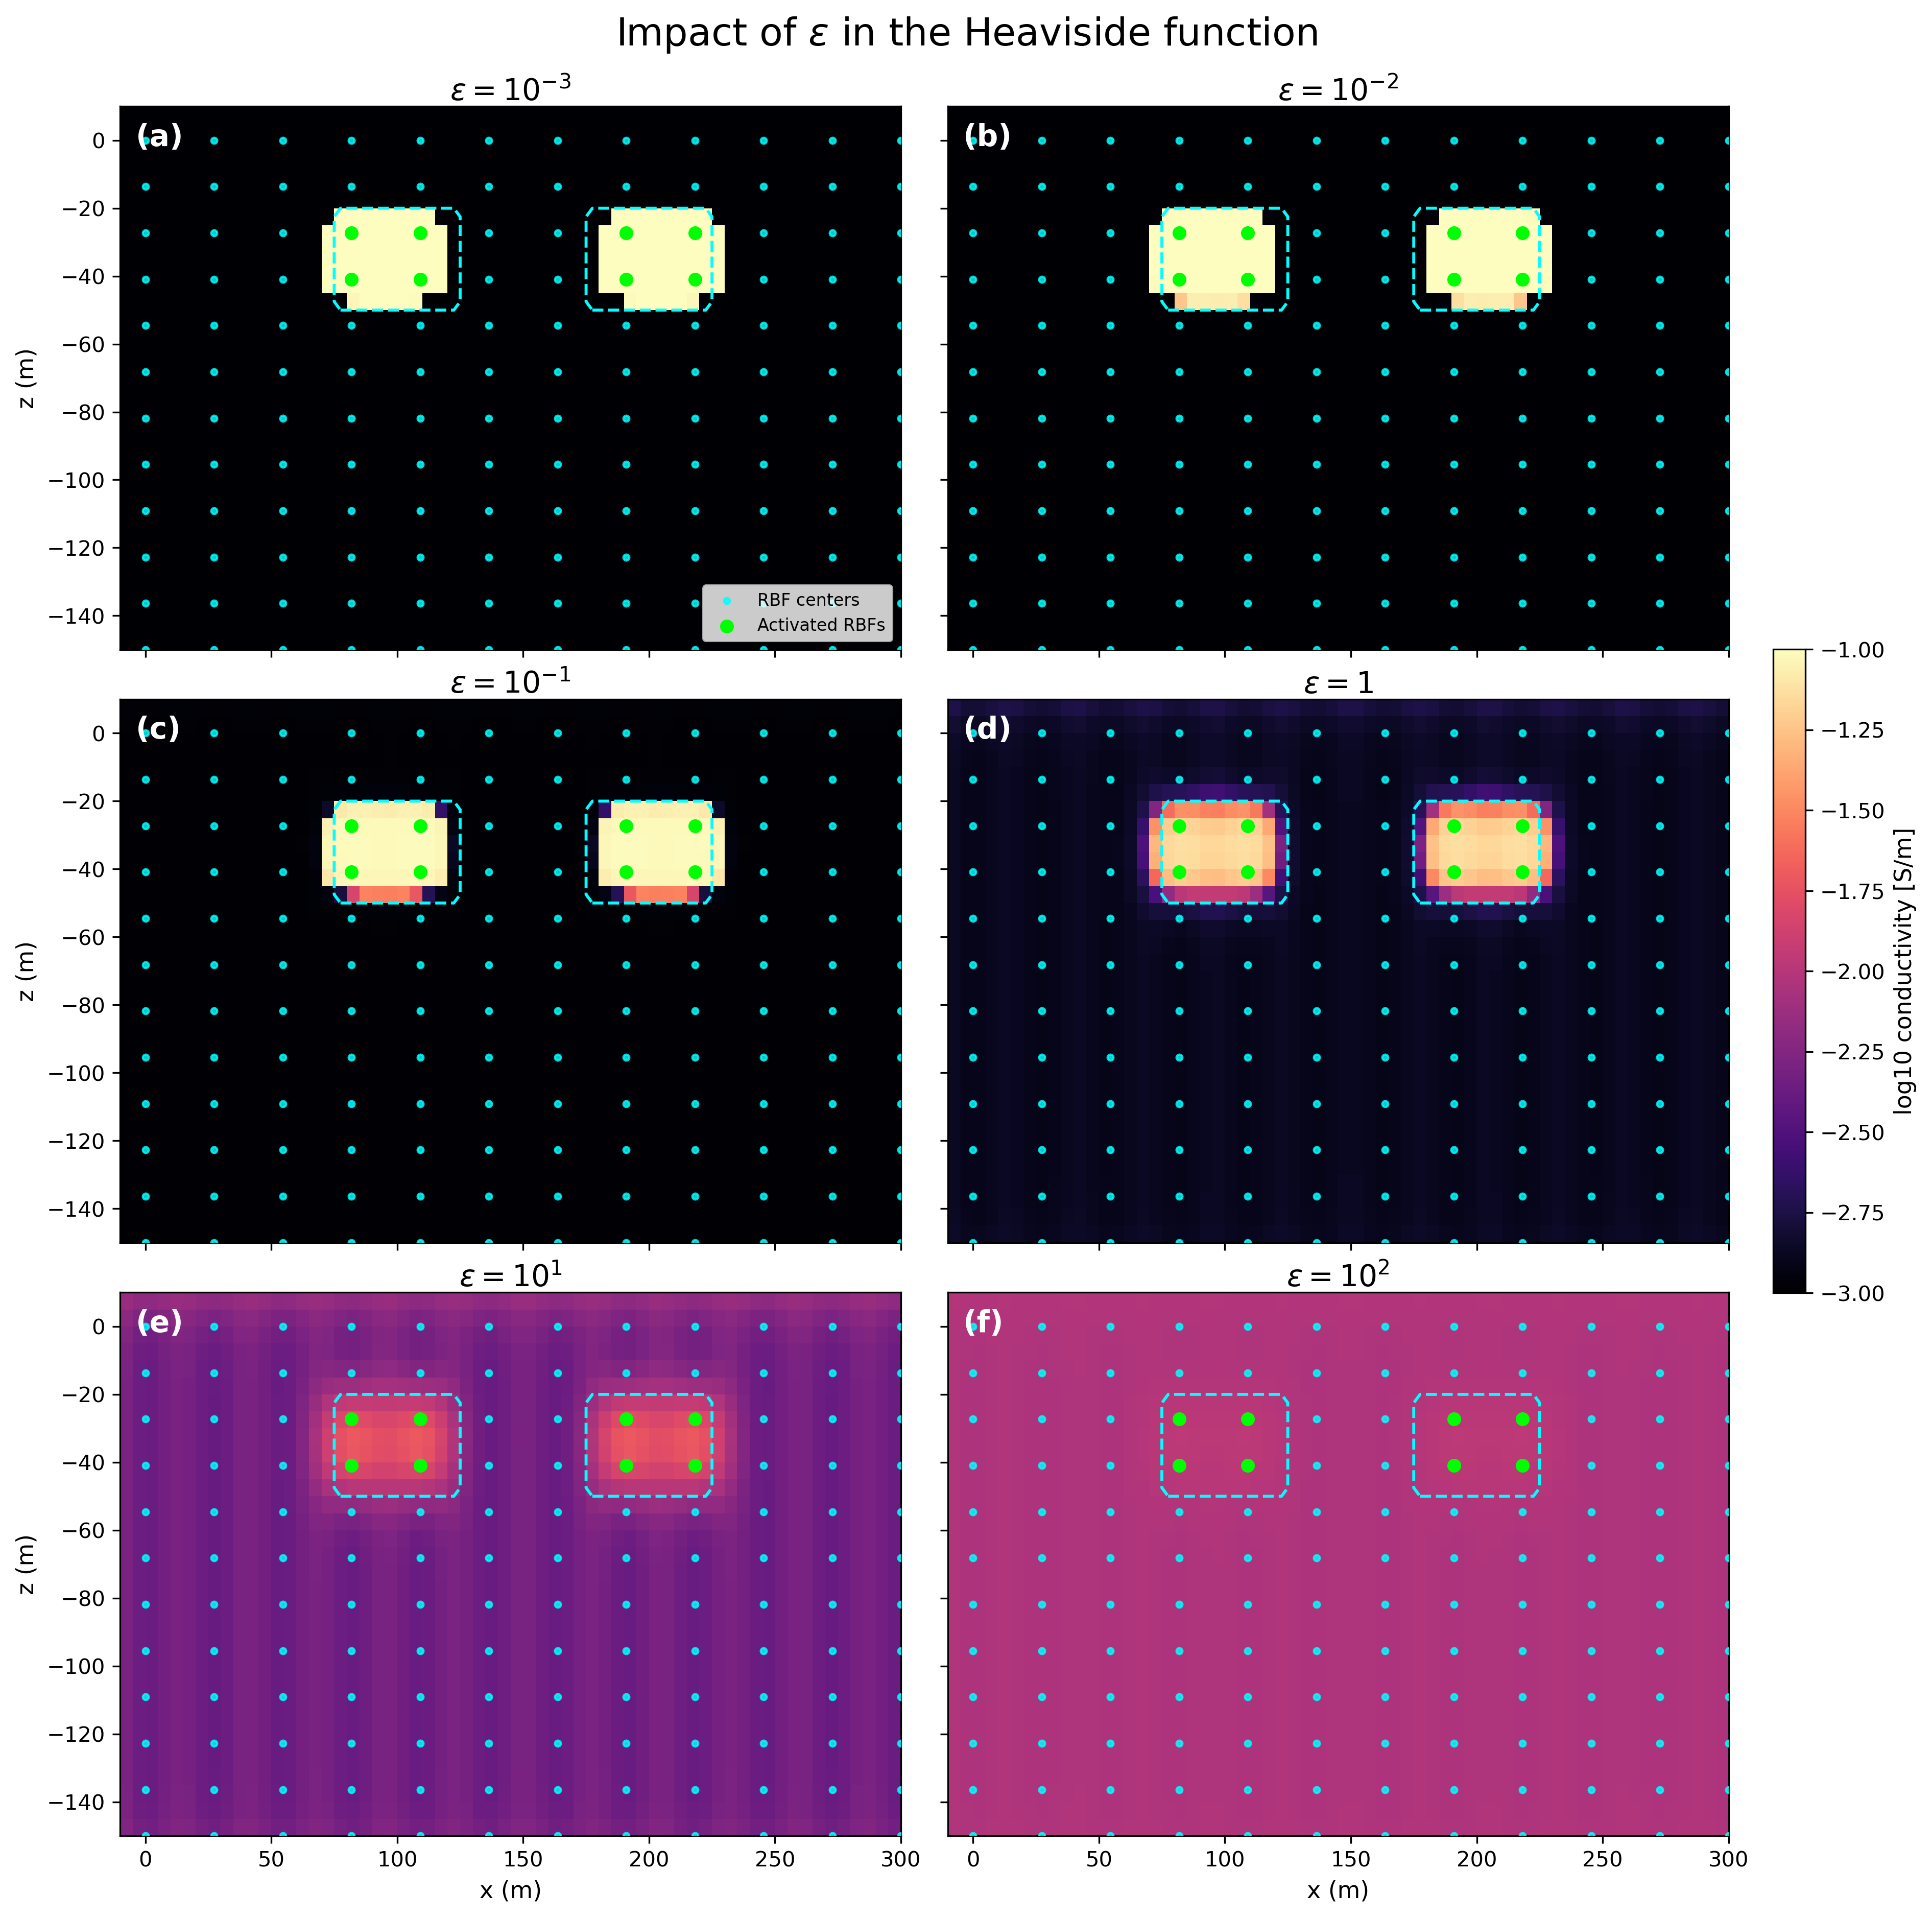

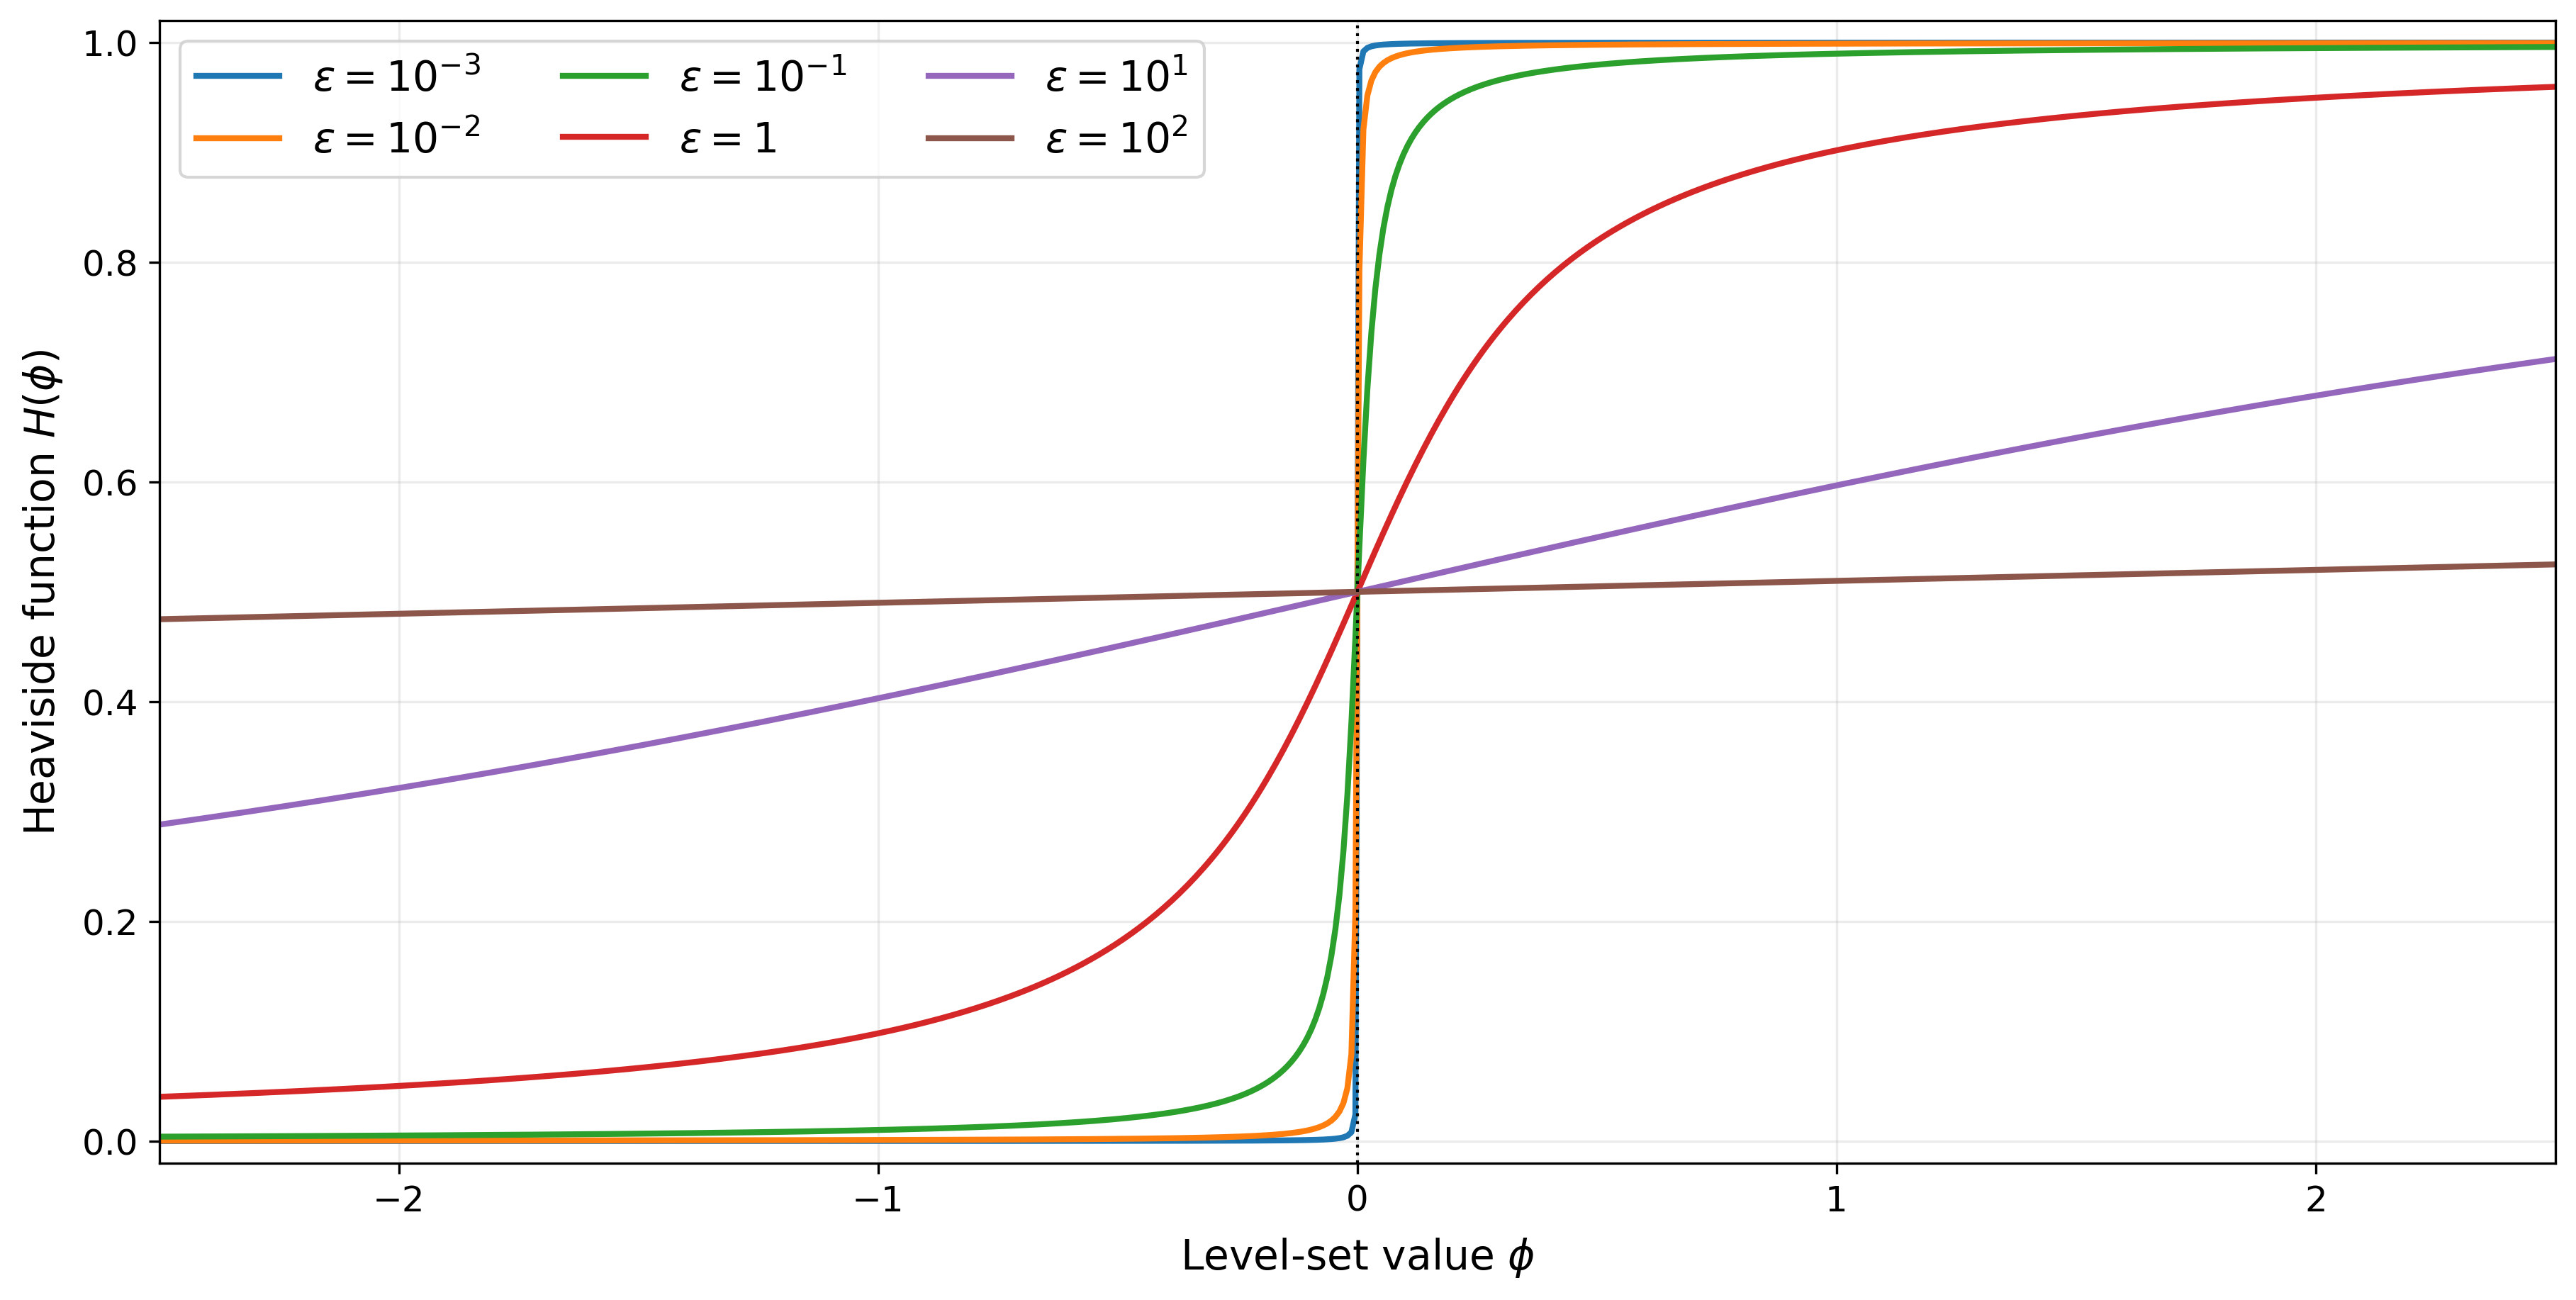

In [17]:
def evaluate_rbf_level_set(eps_value, alpha_vec=None):
    """Evaluate log-conductivity model for a given epsilon."""
    if alpha_vec is None:
        alpha_vec = alpha_init

    alpha_vec = np.asarray(alpha_vec, dtype=float)
    centers = np.asarray(rbf_centers, dtype=float)
    widths = np.asarray(rbf_w, dtype=float)

    alpha_bounded = alpha_bound(alpha_vec)
    distances = cdist(mesh.cell_centers, centers, metric='euclidean')
    psi = np.exp(-((distances**2) / (widths[np.newaxis, :]**2)))
    phi = psi @ alpha_bounded

    arg = np.pi * phi / eps_value
    H = 0.5 * (1.0 + (2.0 / np.pi) * np.arctan(arg))
    log_sigma_model = sigma_background + (sigma_anomaly - sigma_background) * H
    return log_sigma_model, phi, H


eps_powers = [-3, -2, -1, 0, 1, 2]
eps_values = [10.0**p for p in eps_powers]

TITLE_FS = 18
SUBTITLE_FS = 14
LABEL_FS = 11
TICK_FS = 10
LEGEND_FS = 12
MAP_TITLE_PAD = 2
TOP_TITLE_Y = 1.03
G_LABEL_FS = 14
G_TICK_FS = 12
G_LEGEND_FS = 14

show_rbf_centers = True
show_activated_rbf = True
activated_rbf = alpha_init > 0

# --- Figure 1: Models a-f ---
fig, axes = plt.subplots(
    3, 2,
    figsize=(12.5, 12),
    dpi=300,
    constrained_layout=True
)
axes_flat = axes.ravel()

clim = [np.log10(np.exp(sigma_background)), np.log10(np.exp(sigma_anomaly))]
x_c, z_c, block1_grid = get_contour_arrays(mesh, block_inds.astype(float))
_, _, block2_grid = get_contour_arrays(mesh, block_inds_2.astype(float))

model_axes = []
last_img = None
phi_min_global = np.inf
phi_max_global = -np.inf

for i, (eps_val, eps_pow) in enumerate(zip(eps_values, eps_powers)):
    ax = axes_flat[i]
    model_axes.append(ax)

    log_sigma_model, phi_model, _ = evaluate_rbf_level_set(eps_val, alpha_init)
    phi_min_global = min(phi_min_global, phi_model.min())
    phi_max_global = max(phi_max_global, phi_model.max())
    log10_sigma_model = np.log10(np.exp(log_sigma_model))

    last_img = mesh.plot_image(
        log10_sigma_model,
        ax=ax,
        grid=False,
        clim=clim,
        pcolor_opts={"cmap": "magma"},
    )[0]

    ax.contour(
        x_c, z_c, block1_grid,
        levels=[0.5],
        colors="cyan",
        linewidths=1.4,
        linestyles="--",
    )
    ax.contour(
        x_c, z_c, block2_grid,
        levels=[0.5],
        colors="cyan",
        linewidths=1.4,
        linestyles="--",
    )

    if show_rbf_centers:
        ax.scatter(
            rbf_centers[:, 0],
            rbf_centers[:, 1],
            s=8,
            c="cyan",
            alpha=0.8,
            linewidths=1,
            zorder=3,
            label="RBF centers" if i == 0 else None,
        )

    if show_activated_rbf:
        ax.scatter(
            rbf_centers[activated_rbf, 0],
            rbf_centers[activated_rbf, 1],
            s=28,
            facecolors="lime",
            edgecolors="lime",
            linewidths=1.2,
            zorder=4,
            label="Activated RBFs" if i == 0 else None,
        )

    # ax.scatter(
    #     electrode_locations[:, 0],
    #     electrode_locations[:, 1],
    #     s=16,
    #     c="white",
    #     edgecolors="black",
    #     linewidths=0.5,
    #     alpha=0.9,
    #     zorder=5,
    # )

    eps_label = rf"$\epsilon=10^{{{eps_pow}}}$" if eps_pow != 0 else r"$\epsilon=1$"
    ax.set_title(eps_label, fontsize=SUBTITLE_FS, pad=MAP_TITLE_PAD)

    row, col = divmod(i, 2)
    ax.set_xlabel("x (m)" if row == 2 else "", fontsize=LABEL_FS)
    ax.set_ylabel("z (m)" if col == 0 else "", fontsize=LABEL_FS)
    ax.tick_params(
        axis="both",
        labelsize=TICK_FS,
        labelbottom=(row == 2),
        labelleft=(col == 0),
    )

    panel_letter = chr(ord("a") + i)
    ax.text(
        0.02, 0.97, f"({panel_letter})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=SUBTITLE_FS,
        fontweight="bold",
        color="white",
    )

if show_rbf_centers or show_activated_rbf:
    model_axes[0].legend(loc="lower right", fontsize=8, frameon=True)

cbar = fig.colorbar(last_img, ax=model_axes, fraction=0.02, pad=0.015)
cbar.set_label("log10 conductivity [S/m]", fontsize=LABEL_FS)
cbar.ax.tick_params(labelsize=TICK_FS)

fig.suptitle(
    "Impact of $\\epsilon$ in the Heaviside function",
    fontsize=TITLE_FS,
    y=TOP_TITLE_Y,
 )
plt.show()

# --- Figure 2: Heaviside Function ---
fig2, ax_t = plt.subplots(figsize=(12, 6), dpi=300, constrained_layout=True)

phi_plot = np.linspace(-2.5, 2.5, 600)
for eps_val, eps_pow in zip(eps_values, eps_powers):
    H_curve = 0.5 * (1.0 + (2.0 / np.pi) * np.arctan((np.pi * phi_plot) / eps_val))
    eps_label = rf"$\epsilon=10^{{{eps_pow}}}$" if eps_pow != 0 else r"$\epsilon=1$"
    ax_t.plot(phi_plot, H_curve, linewidth=2, label=eps_label)

ax_t.axvline(0, color="k", linestyle=":", linewidth=1)
ax_t.set_xlim(phi_plot.min(), phi_plot.max())
ax_t.set_ylim(-0.02, 1.02)
ax_t.set_xlabel(r"Level-set value $\phi$", fontsize=G_LABEL_FS, labelpad=6)
ax_t.set_ylabel(r"Heaviside function $H(\phi)$", fontsize=G_LABEL_FS, labelpad=6)
ax_t.tick_params(axis="both", labelsize=G_TICK_FS)
ax_t.grid(alpha=0.25)
ax_t.legend(ncol=3, frameon=True, fontsize=G_LEGEND_FS)
# ax_t.text(
#     0.02, 0.97, "(g)",
#     transform=ax_t.transAxes,
#     ha="left",
#     va="top",
#     fontsize=SUBTITLE_FS,
#     fontweight="bold",
# )

plt.show()

### Beta Hyperparameter Impact Figure ($\beta = 1/rbf_w$)

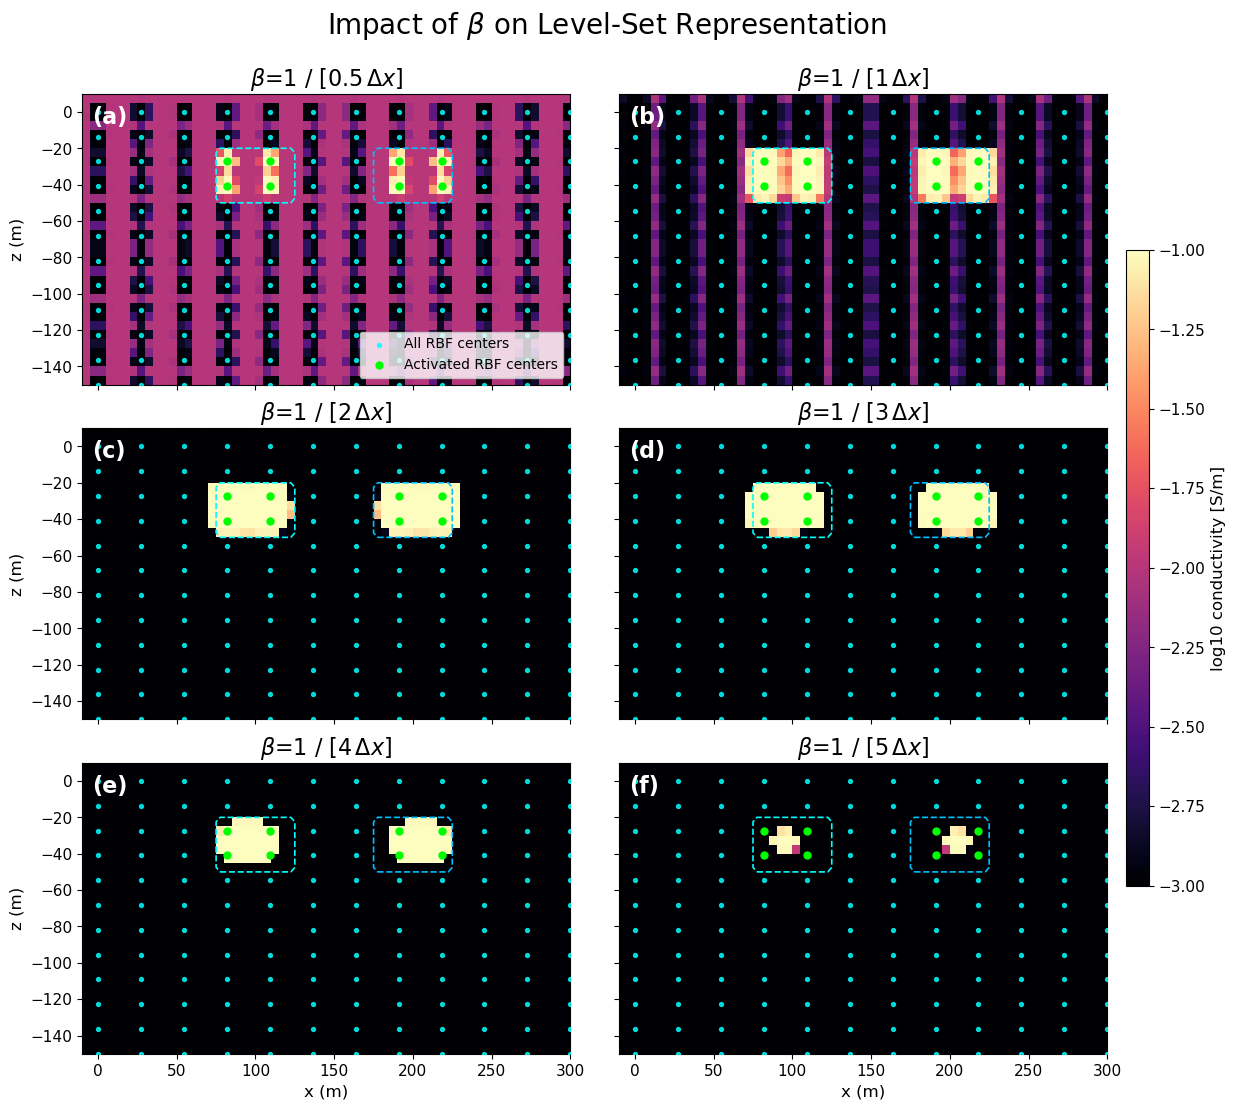

In [15]:
# Test impact of beta = 1 / rbf_w using width multipliers of mesh spacing
mesh_spacing = min(dx, dz)
width_multipliers = [0.5, 1, 2, 3, 4, 5]
rbf_width_values = [m * mesh_spacing for m in width_multipliers]
beta_values = [1.0 / w for w in rbf_width_values]

eps_fixed = 0.01

def evaluate_level_set_with_width(width_value, alpha_vec=None, eps_value=10.0):
    if alpha_vec is None:
        alpha_vec = alpha_init

    alpha_vec = np.asarray(alpha_vec, dtype=float)
    centers = np.asarray(rbf_centers, dtype=float)
    widths = np.full(centers.shape[0], float(width_value))

    alpha_bounded = alpha_bound(alpha_vec)
    distances = cdist(mesh.cell_centers, centers, metric='euclidean')
    psi = np.exp(-((distances**2) / (widths[np.newaxis, :]**2)))
    phi = psi @ alpha_bounded

    arg = np.pi * phi / eps_value
    H = 0.5 * (1.0 + (2.0 / np.pi) * np.arctan(arg))
    log_sigma_model = sigma_background + (sigma_anomaly - sigma_background) * H
    return log_sigma_model, phi

TITLE_FS = 20
SUBTITLE_FS = 16
LABEL_FS = 12
TICK_FS = 11
LEGEND_FS = 10

fig, axes = plt.subplots(
    3, 2,
    figsize=(12.5, 12),
    sharex=True,
    sharey=True,
    constrained_layout=False,
    gridspec_kw={"left": 0.08, "right": 0.90, "bottom": 0.10, "top": 0.90, "wspace": 0.10, "hspace": 0.15},
)
axes = axes.ravel()

clim = [np.log10(np.exp(sigma_background)), np.log10(np.exp(sigma_anomaly))]
x_c, z_c, block1_grid = get_contour_arrays(mesh, block_inds.astype(float))
_, _, block2_grid = get_contour_arrays(mesh, block_inds_2.astype(float))

show_centers = True
show_active_only = True
active_mask = alpha_init > 0

last_img = None
for i, (scale, width_value, beta_value) in enumerate(zip(width_multipliers, rbf_width_values, beta_values)):
    ax = axes[i]
    log_sigma_model, _ = evaluate_level_set_with_width(width_value, alpha_init, eps_fixed)
    log10_sigma_model = np.log10(np.exp(log_sigma_model))

    last_img = mesh.plot_image(
        log10_sigma_model,
        ax=ax,
        grid=False,
        clim=clim,
        pcolor_opts={"cmap": "magma"},
    )[0]

    ax.contour(
        x_c, z_c, block1_grid,
        levels=[0.5],
        colors="cyan",
        linewidths=1.2,
        linestyles="--",
    )
    ax.contour(
        x_c, z_c, block2_grid,
        levels=[0.5],
        colors="deepskyblue",
        linewidths=1.2,
        linestyles="--",
    )

    if show_centers:
        ax.scatter(
            rbf_centers[:, 0], rbf_centers[:, 1],
            s=8, c="cyan", alpha=0.80, linewidths=1, zorder=3,
            label="All RBF centers" if i == 0 else None,
        )

    if show_active_only:
        ax.scatter(
            rbf_centers[active_mask, 0], rbf_centers[active_mask, 1],
            s=24, facecolors="lime", edgecolors="lime", linewidths=1.1, zorder=4,
            label="Activated RBF centers" if i == 0 else None,
        )

    # ax.scatter(
    #     electrode_locations[:, 0], electrode_locations[:, 1],
    #     s=14, c="white", edgecolors="black", linewidths=0.4, alpha=0.85, zorder=5,
    # )

    ax.set_title(
        #rf"$\beta=\frac{{1}}{{{scale:g}\,\Delta x}}$",
        rf"$\beta$=1 / [${{{scale:g}\,\Delta x}}]$",
        fontsize=SUBTITLE_FS,
    )

    row, col = divmod(i, 2)
    ax.set_xlabel("x (m)" if row == 2 else "", fontsize=LABEL_FS)
    ax.set_ylabel("z (m)" if col == 0 else "", fontsize=LABEL_FS)
    ax.tick_params(
        axis="both",
        labelsize=TICK_FS,
        labelbottom=(row == 2),
        labelleft=(col == 0),
    )

    panel_letter = chr(ord("a") + i)
    ax.text(
        0.02, 0.96, f"({panel_letter})",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=SUBTITLE_FS, fontweight="bold", color="white",
    )

if show_centers or show_active_only:
    axes[0].legend(loc="lower right", fontsize=LEGEND_FS, frameon=True)

# Dedicated colorbar axis to avoid overlap
cax = fig.add_axes([0.915, 0.24, 0.018, 0.53])
cbar = fig.colorbar(last_img, cax=cax)
cbar.set_label("log10 conductivity [S/m]", fontsize=LABEL_FS)
cbar.ax.tick_params(labelsize=TICK_FS)

fig.suptitle(
    r"Impact of $\beta$ on Level-Set Representation",
    fontsize=TITLE_FS,
    y=0.97,
 )
plt.show()

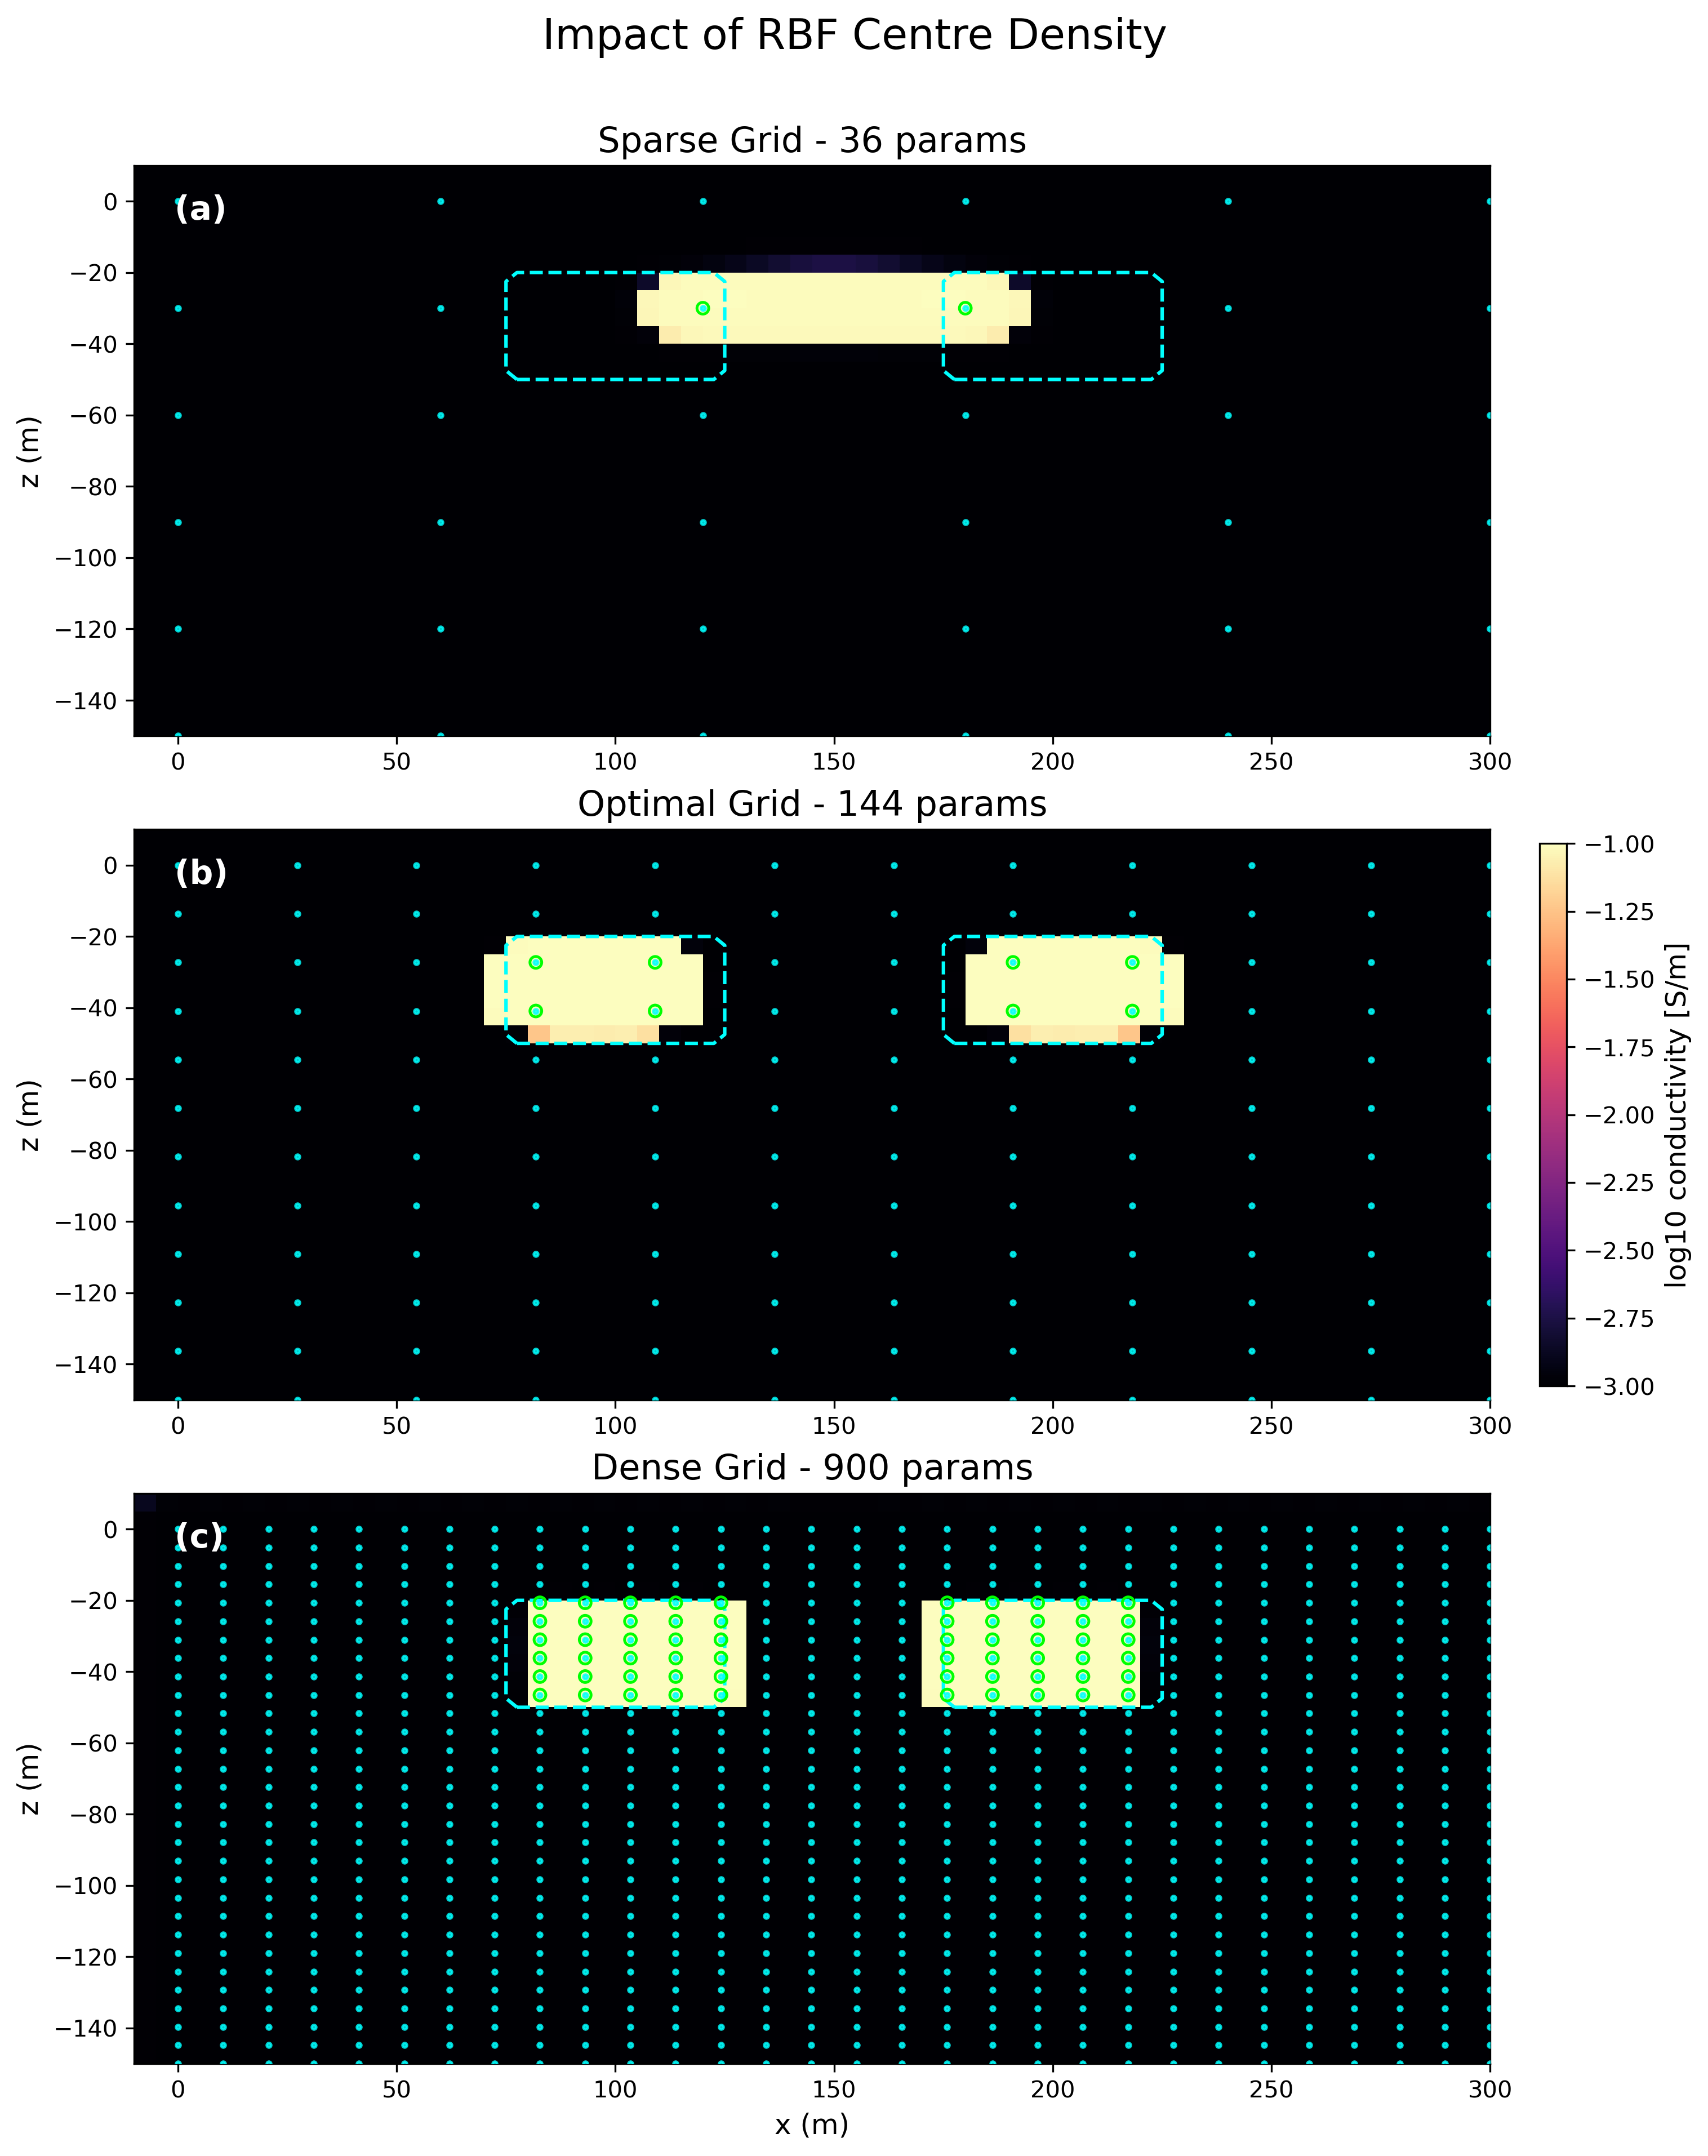

In [23]:
# --- Impact of RBF Centers Quantity Figure ---
def evaluate_density(n_x, n_z, eps_val=0.01):
    # 1. Generate local grid
    r_x = np.linspace(0, 300, n_x)
    r_z = np.linspace(-150, 0, n_z)
    r_xx, r_zz = np.meshgrid(r_x, r_z)
    loc_centers = np.c_[r_xx.ravel(), r_zz.ravel()]
    
    # 2. Local widths (using median spacing like before)
    r_dist = cdist(loc_centers, loc_centers, metric='euclidean')
    np.fill_diagonal(r_dist, np.inf)
    spacing = np.median(np.min(r_dist, axis=1))
    loc_widths = np.full(loc_centers.shape[0], spacing)
    
    # 3. Setup initial alpha weights
    loc_alpha = -5.0 * np.ones(loc_centers.shape[0])
    buffer = 0
    b1_inds = np.all((loc_centers >= [block_x1[0]-buffer, block_z1[0]-buffer]) & 
                     (loc_centers <= [block_x1[1]+buffer, block_z1[1]+buffer]), axis=1)
    b2_inds = np.all((loc_centers >= [block_x2[0]-buffer, block_z2[0]-buffer]) & 
                     (loc_centers <= [block_x2[1]+buffer, block_z2[1]+buffer]), axis=1)
    loc_alpha[b1_inds] = 5.0
    loc_alpha[b2_inds] = 5.0
    
    # 4. Evaluate Level Set
    a_bounded = alpha_bound(loc_alpha)
    distances = cdist(mesh.cell_centers, loc_centers, metric='euclidean')
    psi = np.exp(-((distances**2) / (loc_widths[np.newaxis, :]**2)))
    phi = psi @ a_bounded
    
    arg = np.pi * phi / eps_val
    H = 0.5 * (1.0 + (2.0 / np.pi) * np.arctan(arg))
    log_sigma = sigma_background + (sigma_anomaly - sigma_background) * H
    
    return log_sigma, loc_centers, loc_alpha

# Configurations: Sparse (36 params), Optimal (144 params), Dense (900 params)
grid_configs = [(6, 6), (12, 12), (30, 30)]
titles = ["Sparse Grid", "Optimal Grid", "Dense Grid"]
letters = ['a', 'b', 'c']

fig, axes = plt.subplots(3, 1, figsize=(10, 12), dpi=300, constrained_layout=True)
axes = axes.ravel()

# Reuse arrays defined previously in the notebook
clim = [np.log10(np.exp(sigma_background)), np.log10(np.exp(sigma_anomaly))]
x_c, z_c, block1_grid = get_contour_arrays(mesh, block_inds.astype(float))
_, _, block2_grid = get_contour_arrays(mesh, block_inds_2.astype(float))

for i, (grid, ax) in enumerate(zip(grid_configs, axes)):
    log_sigma, centers, alphas = evaluate_density(grid[0], grid[1])
    log10_sigma = np.log10(np.exp(log_sigma))
    
    img = mesh.plot_image(log10_sigma, ax=ax, grid=False, clim=clim, pcolor_opts={"cmap": "magma"})[0]
    
    # Highlight true shapes
    ax.contour(x_c, z_c, block1_grid, levels=[0.5], colors="cyan", linewidths=1.5, linestyles="--")
    ax.contour(x_c, z_c, block2_grid, levels=[0.5], colors="cyan", linewidths=1.5, linestyles="--")
    
    # Overlay RBF centers
    ax.scatter(centers[:, 0], centers[:, 1], s=4, c="cyan", alpha=0.8, linewidths=1, zorder=3)
    active_mask = alphas > 0
    ax.scatter(centers[active_mask, 0], centers[active_mask, 1], s=25, facecolors="none", edgecolors="lime", linewidths=1.2, zorder=4)
    
    ax.set_title(f"{titles[i]} - {grid[0]*grid[1]} params", fontsize=15)
    ax.set_xlabel("x (m)" if i == 2 else "", fontsize=12)
    ax.set_ylabel("z (m)", fontsize=12)
    
    ax.text(0.03, 0.95, f"({letters[i]})", transform=ax.transAxes, ha="left", va="top", fontsize=14, fontweight="bold", color="white")

cbar = fig.colorbar(img, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label("log10 conductivity [S/m]", fontsize=12)
fig.suptitle("Impact of RBF Centre Density", fontsize=18, y=1.05)
plt.show()

Non-negative alpha indices: [ 99 100 103 104 111 112 115 116]


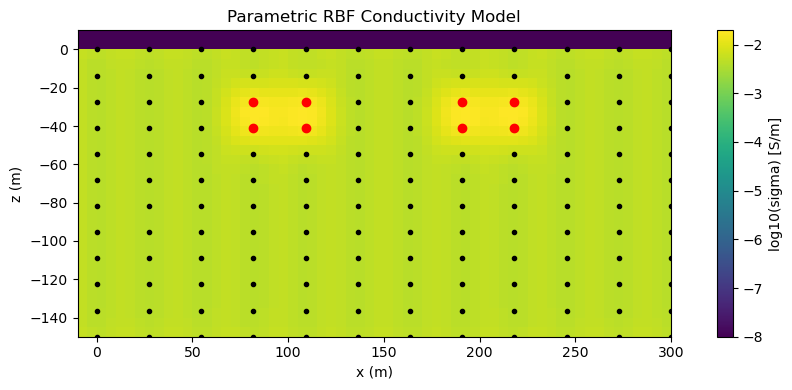

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plot_with_colorbar(mesh, np.log10(param_model), ax, label='log10(sigma) [S/m]')
plt.scatter(rbf_centers[:, 0], rbf_centers[:, 1], c='k', marker='.', label='RBF Centers')
#show rbfs associated with non-negative alpha parameters
non_negative_inds = np.where(params >= 0)[0]
print(f"Non-negative alpha indices: {non_negative_inds}")
plt.scatter(rbf_centers[non_negative_inds, 0], rbf_centers[non_negative_inds, 1], c='r', marker='o', label='Non-negative alphas')
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title('Parametric RBF Conductivity Model')
plt.tight_layout()
plt.show() 

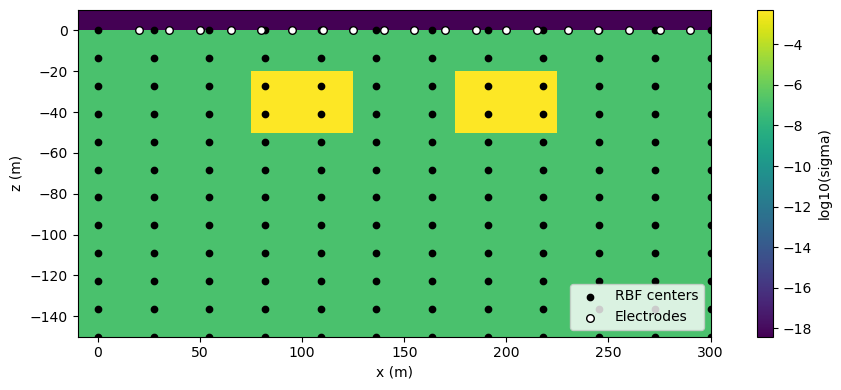

In [36]:
# Visualize RBF centers (density parameterization)
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plot_with_colorbar(mesh, (sigma_true), ax, label='log10(sigma)')
ax.scatter(rbf_centers[:, 0], rbf_centers[:, 1], c='black', s=50, marker='.', 
           linewidths=2, label='RBF centers')
# plot electrode locations
ax.scatter(electrode_locations[:, 0], electrode_locations[:, 1], c='white', s=30, marker='o', 
           edgecolors='black', label='Electrodes')
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
#ax.set_title('RBF Centers overlaid on True Model')
ax.legend()
plt.tight_layout()
plt.show()

## Level Set Inversion

In [71]:
from simpeg import data_misfit, regularization, optimization, inverse_problem, directives, inversion
# 1. Setup Simulation with ExpMap (solve for log-conductivity)
expmap = maps.ExpMap(mesh)

# 2. Data Misfit

simulation_param = dc.Simulation2DNodal(
    mesh, survey=survey, sigmaMap=param_map)

dmisfit = data_misfit.L2DataMisfit(
    data=simpeg_data.Data(survey, dobs=data_obs, standard_deviation=noise_std), 
    simulation=simulation_param
)

# 3. Regularization (Weighted Least Squares)
reg = regularization.WeightedLeastSquares(
    TensorMesh([np.ones_like(params)]), 
)


# 4. Optimization
opt = optimization.InexactGaussNewton(maxIter=5, maxIterCG=10)


# 5. Inverse Problem
inv_prob = inverse_problem.BaseInvProblem(dmisfit, reg, opt, beta=0)

# 6. Directives
beta_est = directives.BetaEstimate_ByEig(beta0_ratio=1.0)
target = directives.TargetMisfit(chifact=1.0)
beta_sched = directives.BetaSchedule(coolingFactor=2.0, coolingRate=1)
sensitivity_weights = directives.UpdateSensitivityWeights()
save_models = directives.SaveModelEveryIteration()
inv = inversion.BaseInversion(inv_prob, directiveList=[target])


INFO: Setting the default solver 'Pardiso' for the 'Simulation2DNodal'.
To avoid receiving this message, pass a solver to the simulation. For example:

  from simpeg.utils import get_default_solver

  solver = get_default_solver()
  simulation = Simulation2DNodal(solver=solver, ...)


In [72]:
# 7. Run Inversion
m0 = params
print("RUNNING INVERSION")
m_opt = inv.run(m0)
sigma_l2 = param_map * m_opt


INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 81.0


RUNNING INVERSION

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  0.00e+00  9.97e+04  0.00e+00  9.97e+04                                 
   1  0.00e+00  3.11e+04  1.34e+11  3.11e+04    5.15e-01      0              
------------------------- STOP! -------------------------
0 : |fc-fOld| = 6.8585e+04 <= tolF*(1+|f0|) = 9.9699e+03
0 : |xc-x_last| = 3.5165e+05 <= tolX*(1+|x0|) = 4.3426e+00
1 : |proj(x-g)-x|    = 3.6867e-05 <= tolG          = 1.0000e-01
1 : |proj(x-g)-x|    = 3.6867e-05 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =       5    <= iter          =      1
------------------------- DONE! -------------------------
